# Descriptors & Laplacians




## 0. Setup

Everything runs on `numpy`, `scipy`, `matplotlib`, `trimesh`. No mesh files are
needed — we generate one procedurally so the notebook is self-contained.

In [1]:
%matplotlib inline
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import trimesh

np.set_printoptions(precision=4, suppress=True)

## 1. What we are building

A **feature descriptor** assigns to every point $x$ on a shape a vector that
characterizes that point in relation to the whole shape. WKS produces, per vertex,
an $M$-dimensional vector — one number per energy level. The descriptor is
*intrinsic*: it is built only from quantities that survive bending the shape
without stretching it, so the same anatomical point on two poses gets nearly the
same vector. That is the whole point of the construction.

The descriptor is the *output*. The Laplacian, the eigenproblem, and the WKS
formula are the machinery that produces it. We build that machinery bottom-up.

## 2. The mesh $(V, F)$

The only input is a triangle mesh: vertex positions $V \in \mathbb{R}^{n\times 3}$
and triangles $F \in \mathbb{Z}^{m\times 3}$. We take a subdivided icosphere and
deform it into a bumpy blob, purely so the eigenfunctions below are visually
non-trivial (a perfect sphere gives spherical harmonics — clean, but bland). In total, we'll have n vertices and m triangles. 

In [2]:
m = trimesh.creation.icosphere(subdivisions=3)
V = np.asarray(m.vertices, float)
F = np.asarray(m.faces, int)
# non-isometric deformation -> interesting geometry
V = V * (1.0 + 0.35*np.sin(3*V[:, 0:1])*np.cos(2*V[:, 1:2]))
n = V.shape[0]
print(f"{n} vertices, {F.shape[0]} faces")

642 vertices, 1280 faces


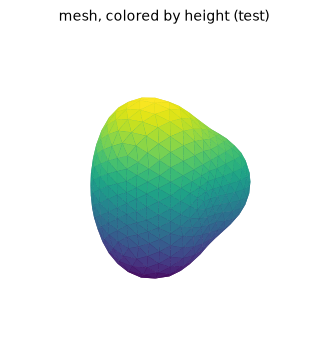

In [3]:
def plot_mesh_scalar(V, F, scalar, ax, cmap="viridis", title=None):
    # Color a triangle mesh by a per-vertex scalar field.
    tris = V[F]
    face_val = scalar[F].mean(axis=1)      # average vertex values per face
    pc = Poly3DCollection(tris, cmap=cmap, edgecolor=(0, 0, 0, 0.04), linewidths=0.15)
    pc.set_array(face_val)
    ax.add_collection3d(pc)
    lim = np.abs(V).max()
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1)); ax.axis("off")
    ax.view_init(elev=20, azim=30)
    if title: ax.set_title(title, fontsize=10)
    return pc

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection="3d")
plot_mesh_scalar(V, F, V[:, 2], ax, title="mesh, colored by height (test)")
plt.show()

## 3. The Laplace–Beltrami operator: cotangent Laplacian + mass matrix

Everything downstream is a weighting of this operator's spectrum, so this is *the*
object. Discretized, the continuous $\Delta$ becomes a pair of sparse
$n\times n$ matrices.

**Stiffness (cotangent) matrix $L$.** For an interior edge $(i,j)$ with the two
opposite angles $\alpha_{ij}$ and $\beta_{ij}$,

$$
L_{ij} = -\tfrac{1}{2}\left(\cot\alpha_{ij} + \cot\beta_{ij}\right),
\qquad
L_{ii} = -\sum_{j\neq i} L_{ij}.
$$

The weights are angles — intrinsic quantities — which is *why* the resulting
descriptor is bending-invariant. We build $L$ positive semidefinite (the $-\Delta$
convention), so its eigenvalues come out $\ge 0$.

**Mass matrix $M$.** The lumped (barycentric) mass matrix is diagonal, with
$M_{ii} = \tfrac{1}{3}\sum_{t \ni i} \operatorname{area}(t)$ — one third of the
area of each triangle touching vertex $i$. It encodes how much surface area each
vertex represents, and it is what makes the eigenproblem *generalized* rather than
plain.


In [4]:
def cotangent_laplacian(V, F):
    I, J, W = [], [], []
    mass = np.zeros(len(V))
    for (i, j, k) in F:
        vi, vj, vk = V[i], V[j], V[k]
        area = 0.5*np.linalg.norm(np.cross(vj - vi, vk - vi))
        mass[[i, j, k]] += area/3.0
        # for each vertex a, cot of angle at a weights the OPPOSITE edge (b,c)
        for a, b, c in [(i, j, k), (j, k, i), (k, i, j)]:
            u, w = V[b] - V[a], V[c] - V[a]
            cot = np.dot(u, w) / (np.linalg.norm(np.cross(u, w)) + 1e-12)
            I += [b, c, b, c]; J += [c, b, b, c]
            W += [-0.5*cot, -0.5*cot, 0.5*cot, 0.5*cot]
    L = sp.csr_matrix((W, (I, J)), shape=(len(V), len(V)))
    M = sp.diags(mass)
    return L, M

L, M = cotangent_laplacian(V, F)
print("L is symmetric:", abs(L - L.T).max() < 1e-12)
print("M positive:", (M.diagonal() > 0).all())

L is symmetric: True
M positive: True


**Intuition check — the Laplacian measures roughness.** Apply $M^{-1}L$ to a
noisy field and it responds to local variation; a step of implicit smoothing,
solving $(M + tL)\,x = M x_0$, visibly relaxes bumps. If smoothing looks like
smoothing, $L$ and $M$ are probably right.

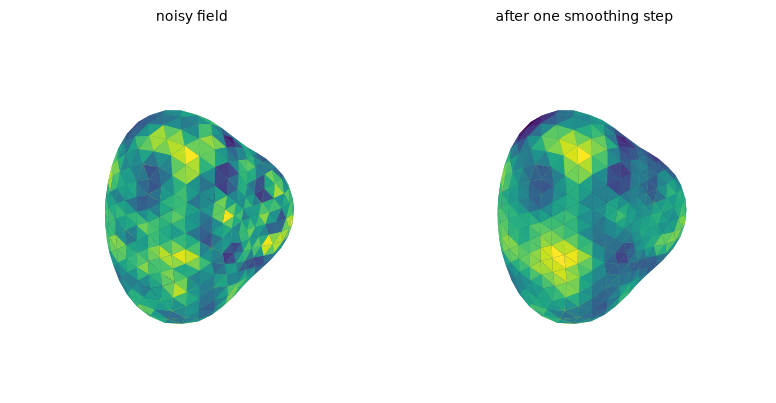

In [5]:
from scipy.sparse.linalg import spsolve
rng = np.random.default_rng(0)
x0 = rng.standard_normal(n)                     # noisy field
t = 0.05
x_smooth = spsolve((M + t*L).tocsc(), M @ x0)   # one implicit smoothing step

fig = plt.figure(figsize=(8, 4))
for idx, (fld, ttl) in enumerate([(x0, "noisy field"), (x_smooth, "after one smoothing step")]):
    ax = fig.add_subplot(1, 2, idx+1, projection="3d")
    plot_mesh_scalar(V, F, fld, ax, title=ttl)
plt.tight_layout(); plt.show()

## 4. The spectrum: solving $L\varphi = \lambda M\varphi$

This is the one numerically interesting step. We want the *smallest* nonzero
eigenvalues (the smooth, low-energy modes) and their eigenvectors.

ARPACK-style solvers (`scipy`'s `eigsh`,
and Spectra in C++) natively find the *largest*-magnitude eigenvalues. To get the
smallest, use **shift-invert** around a shift $\sigma$ near $0$. Note we cannot use
$\sigma = 0$ exactly, because $L$ is singular (the constant mode has eigenvalue
$0$) and the internal factorization of $L - \sigma M$ would fail — so we shift to
$\sigma = -10^{-6}$. In Spectra this is the `SymGEigsShiftSolver` in shift-invert
mode, and this same tiny-shift trick applies.

In [6]:
K = 120
vals, vecs = eigsh(L, k=K, M=M, sigma=-1e-6, which="LM")
order = np.argsort(vals)
vals, vecs = vals[order], vecs[:, order]

print("first eigenvalues:", vals[:6])
print("smallest is ~0 (constant mode):", abs(vals[0]) < 1e-6)
print("eigenvalues non-negative & increasing:", np.all(np.diff(vals) >= -1e-6))

first eigenvalues: [-0.      1.6617  1.8325  1.9166  4.9504  5.3009]
smallest is ~0 (constant mode): True
eigenvalues non-negative & increasing: True


**Intuition check — eigenfunctions are vibration modes.** Coloring the mesh
by $\varphi_k$ should show smooth, global patterns for small $k$, growing more
oscillatory and local as $k$ increases — exactly the standing-wave modes of a
drum. This picture *is* the correctness test for the entire spectral pipeline, and
it is the direct input to WKS. If mode $0$ isn't constant or the low modes look
like noise, the Laplacian or the solve is wrong.

(Eigenvector signs are arbitrary — the solver may return $\varphi_k$ or
$-\varphi_k$. This never matters, because every descriptor in this family uses
$\varphi_k^2$, which kills the sign.)

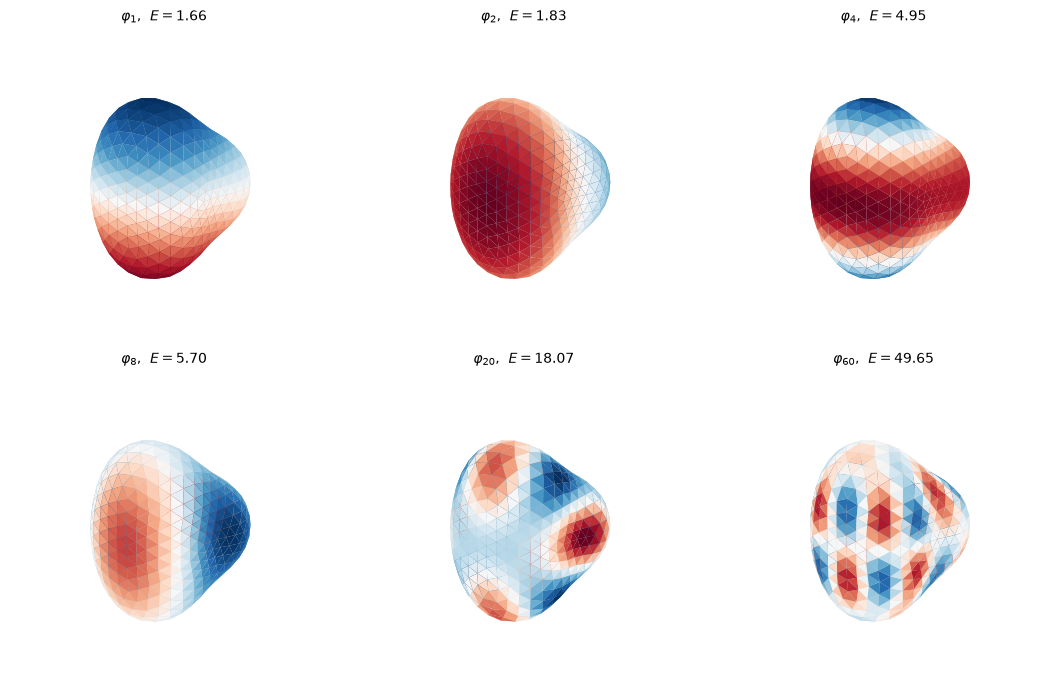

In [7]:
modes = [1, 2, 4, 8, 20, 60]
fig = plt.figure(figsize=(11, 7))
for p, k in enumerate(modes):
    ax = fig.add_subplot(2, 3, p+1, projection="3d")
    plot_mesh_scalar(V, F, vecs[:, k], ax, cmap="RdBu",
                     title=f"$\\varphi_{{{k}}}$,  $E={vals[k]:.2f}$")
plt.tight_layout(); plt.show()

## 5. From heat to Schrödinger: it is all a weighting of the spectrum

HKS and WKS share one skeleton — a per-vertex sum over the spectrum of
*squared eigenfunctions times a weight on the eigenvalue*:

$$
\text{descriptor}(x) \;=\; \sum_k \big[\text{weight}(E_k)\big]\,\varphi_k(x)^2 .
$$

The **only** difference between the two descriptors is the weight function:

$$
\underbrace{e^{-E_k t}}_{\text{HKS: heat}}
\qquad\text{vs.}\qquad
\underbrace{f_E(E_k)^2}_{\text{WKS: Schr\"odinger}} .
$$

The quantum story exists only to justify the second weight. In the state
$\psi_E(x,t) = \sum_k e^{-iE_k t}\varphi_k(x)\, f_E(E_k)$, the factor $f_E(E_k)$
sits exactly where the usual expansion coefficient $c_k = \langle \varphi_k|\psi\rangle$
sits — it *is* the amplitude of energy eigenstate $k$, specialized to be a
distribution peaked at an approximately-measured energy $E$. Time-averaging
$|\psi_E|^2$ kills the phases and collapses the double sum to the diagonal, leaving
$\sum_k \varphi_k(x)^2 f_E(E_k)^2$.

The consequence is a filtering picture: **HKS is a low-pass filter** (always leans
toward small $E_k$), while **WKS is a band-pass** bump you can center anywhere.
That is why WKS reaches fine-scale information HKS buries.

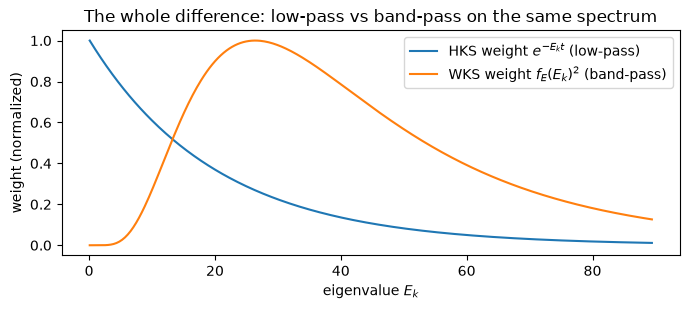

In [8]:
Egrid = np.linspace(0.1, vals[:K].max(), 400)
t_hks = 0.05
hks_w = np.exp(-Egrid * t_hks)                    # low-pass
e_center = np.log(vals[30])                        # one WKS band, in log-energy
sig = 0.6
wks_w = np.exp(-(np.log(Egrid) - e_center)**2 / (2*sig**2))  # band-pass

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(Egrid, hks_w/hks_w.max(), label="HKS weight $e^{-E_k t}$ (low-pass)")
ax.plot(Egrid, wks_w/wks_w.max(), label="WKS weight $f_E(E_k)^2$ (band-pass)")
ax.set_xlabel("eigenvalue $E_k$"); ax.set_ylabel("weight (normalized)")
ax.legend(); ax.set_title("The whole difference: low-pass vs band-pass on the same spectrum")
plt.tight_layout(); plt.show()

## 6. The WKS formula

Working in the **logarithmic energy scale** $e = \log E$ — forced by the stability
analysis, which shows eigen-energies shift *multiplicatively* under deformation, so
their log-shift is roughly constant across the spectrum and a single filter width
fits everywhere. The measurement distribution $f_E^2$ is therefore log-normal, i.e.
a Gaussian in $e$. The descriptor (paper eq. 10):

$$
\text{WKS}(x, e) \;=\; C_e \sum_k \varphi_k(x)^2 \,
\exp\!\left(-\frac{(e - \log E_k)^2}{2\sigma^2}\right),
\qquad
C_e = \left(\sum_k \exp\!\left(-\frac{(e-\log E_k)^2}{2\sigma^2}\right)\right)^{-1}.
$$

$C_e$ is the easy kind of normalization: one division per energy channel, enforcing
that the weights at each scale sum to $1$. The only failure mode is an *empty*
channel — an $e$ far from every $\log E_k$ makes the sum near zero and $1/\text{sum}$
blow up — which the $e_{\min}/e_{\max}$ choice below is designed to avoid.

Paper parameters: drop the zero eigenvalue, take $N$ eigenvalues, evaluate at $M$
energies, $e_{\min} = \log E_1 + 2\sigma$, $e_{\max} = \log E_N - 2\sigma$,
$\sigma = 7\delta$ with $\delta$ the grid spacing.

In [9]:
E = vals.copy(); phi = vecs.copy()
nz = E > 1e-8                      # discard the zero (constant) mode
E, phi = E[nz], phi[:, nz]
logE = np.log(E)

Mch = 100
sigma = 7.0 * (logE.max() - logE.min()) / Mch
emin, emax = logE.min() + 2*sigma, logE.max() - 2*sigma
egrid = np.linspace(emin, emax, Mch)

# gaussian weights: (num_eigen x Mch)
Wgt = np.exp(-(egrid[None, :] - logE[:, None])**2 / (2*sigma**2))
Ce = 1.0 / (Wgt.sum(axis=0) + 1e-12)          # per-ENERGY normalization
WKS = (phi**2) @ Wgt * Ce[None, :]            # (n x Mch): descriptor per vertex

print("WKS shape (vertices x energy channels):", WKS.shape)
print("all finite:", np.isfinite(WKS).all())
print("sigma =", round(sigma, 4), " energy range = [%.2f, %.2f]" % (emin, emax))

WKS shape (vertices x energy channels): (642, 100)
all finite: True
sigma = 0.279  energy range = [1.07, 3.94]


## 7. Visualizing the descriptor

Two views. First, a few **energy channels** painted on the mesh: low-energy
channels respond to global structure, high-energy channels to local detail — the
scale separation that defines WKS.

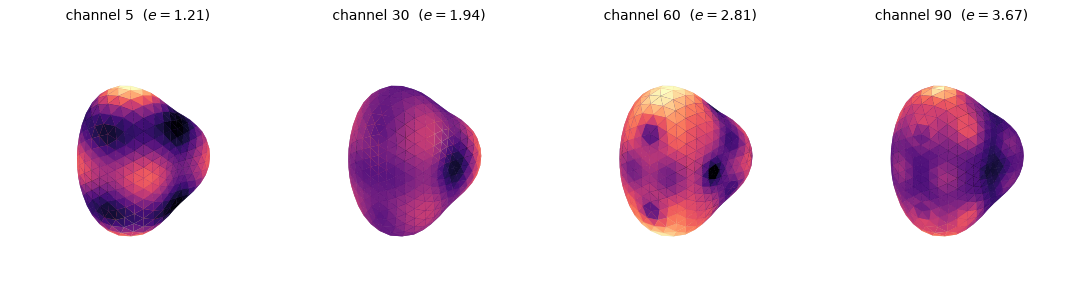

In [10]:
channels = [5, 30, 60, 90]
fig = plt.figure(figsize=(11, 3.2))
for p, c in enumerate(channels):
    ax = fig.add_subplot(1, 4, p+1, projection="3d")
    plot_mesh_scalar(V, F, WKS[:, c], ax, cmap="magma",
                     title=f"channel {c}  ($e={egrid[c]:.2f}$)")
plt.tight_layout(); plt.show()

Second, the **per-point signature** $\text{WKS}(x,\cdot)$ — the actual
descriptor vector at a few vertices, plotted across energy. Points that are
geometrically different produce different curves; this curve *is* what gets
compared when matching two shapes.

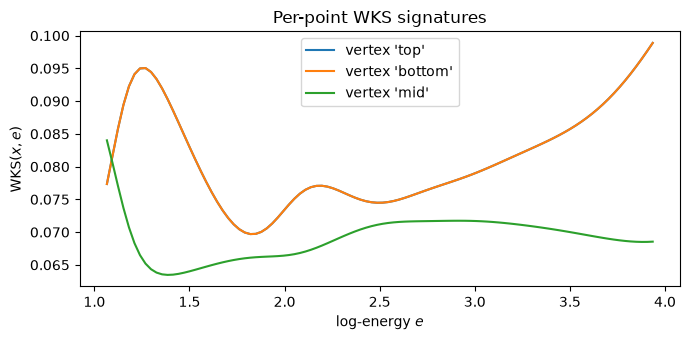

In [11]:
# pick three geometrically distinct vertices: highest, lowest, and median height
zc = V[:, 2]
pts = {"top": int(zc.argmax()), "bottom": int(zc.argmin()),
       "mid": int(np.argsort(zc)[len(zc)//2])}

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, vidx in pts.items():
    ax.plot(egrid, WKS[vidx, :], label=f"vertex '{name}'")
ax.set_xlabel("log-energy $e$"); ax.set_ylabel("WKS$(x,e)$")
ax.set_title("Per-point WKS signatures"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Where this maps back to the C++ task

Every stage above has a direct C++ counterpart, and the visual checks transfer
one-for-one:

- `cotangent_laplacian` $\to$ hand-assembled Eigen sparse `L`, `M`; verify against
  `igl::cotmatrix` / `igl::massmatrix`.
- `eigsh(..., sigma=-1e-6)` $\to$ Spectra `SymGEigsShiftSolver` in shift-invert
  mode near $0$ (the same tiny-shift reason).
- the eigenfunction grid $\to$ color modes in Polyscope; smooth$\to$oscillatory is
  the correctness test.
- the WKS block $\to$ the same closed-form sum; the descriptor is the short part.

The distance $d_{\text{WKS}}(x,y)$ (paper eq. 11) and actual shape matching are the
next layer, once the per-vertex descriptor is trusted.

If a C++ result disagrees with this notebook on the same mesh, the notebook is the
oracle — debug the C++ against it.